In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#suppressing warnings fro clean output
import warnings
warnings.filterwarnings('ignore')

# loading the dataset
df = pd.read_csv(r'C:\Users\91761\OneDrive\Desktop\IIT K Data anlysis\Capstone Project\Financial_Fraud_Detection_Datasets\cc_data.csv')

print('Data Successfully Loaded')

Data Successfully Loaded


In [5]:
# checking dimensions
print(f'Dataset dimensions: {df.shape[0]} rows and {df.shape[1]} columns.\n')

# checking for missing values
missing_values = df.isnull().sum()
missing_values = missing_values[missing_values > 0]

if missing_values.empty:
    print('Mising Values: None. No imputation required')
else:
    print('Missing Values: Detected \n', missing_values)

Dataset dimensions: 389002 rows and 23 columns.

Mising Values: None. No imputation required


In [9]:
# Identifying unique values in categorical variables
categoriacl_cols = df.select_dtypes(include=['object']).columns
print('--- Unique Categoriacal Values ---')
for col in categoriacl_cols:
    print(f'{col}: {df[col].nunique()} unique values')

#genearating summary ststistics for numerical variables
print('\n--- Numerical Summary Statistics ---')
display(df.describe().round(2))

--- Unique Categoriacal Values ---
trans_date_trans_time: 293627 unique values
merchant: 693 unique values
category: 14 unique values
first: 352 unique values
last: 481 unique values
gender: 2 unique values
street: 979 unique values
city: 890 unique values
state: 51 unique values
job: 492 unique values
dob: 964 unique values
trans_num: 389002 unique values

--- Numerical Summary Statistics ---


,index,cc_num,amt,zip,lat,long,city_pop,unix_time,merch_lat,merch_long,is_fraud
count,389002.00,3.890020e+05,389002.00,389002.00,389002.00,389002.00,389002.00,3.890020e+05,389002.00,389002.00,389002.00
mean,648520.51,4.191512e+17,70.44,48818.06,38.53,-90.24,88680.84,1.349251e+09,38.53,-90.24,0.01
std,374574.39,1.311579e+18,162.20,26879.38,5.07,13.75,301210.10,1.285085e+07,5.11,13.76,0.08
min,11.00,6.041621e+10,1.00,1257.00,20.03,-165.67,23.00,1.325376e+09,19.03,-166.67,0.00
25%,324184.25,1.800429e+14,9.66,26237.00,34.62,-96.80,743.00,1.338751e+09,34.72,-96.91,0.00
50%,648648.50,3.521417e+15,47.57,48174.00,39.35,-87.48,2456.00,1.349267e+09,39.36,-87.45,0.00
75%,973503.25,4.642255e+15,83.08,72011.00,41.94,-80.16,20328.00,1.359460e+09,41.96,-80.25,0.00
max,1296674.00,4.992346e+18,27390.12,99783.00,66.69,-67.95,2906700.00,1.371817e+09,67.06,-66.96,1.00


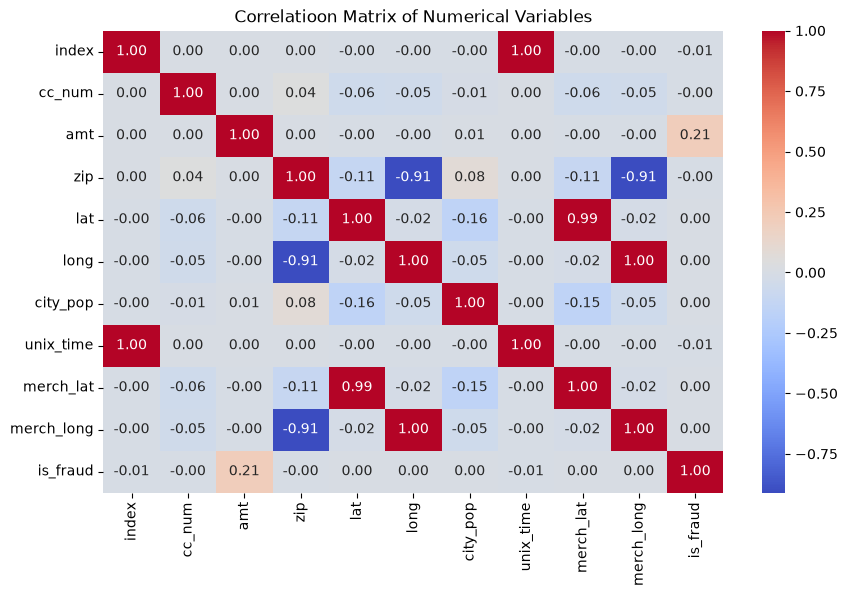

Observation: Check the intersection of 'amt' and 'city_pop' . A value near 0 confirms no correlation.


In [11]:
# selecting only numeric columns

numeric_df = df.select_dtypes(include=[np.number])

#calculating the correlation matrix

corr_matrix = numeric_df.corr()

#ploting the heatmap

plt.figure(figsize=(10,6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlatioon Matrix of Numerical Variables')
plt.show()

print("Observation: Check the intersection of 'amt' and 'city_pop' . A value near 0 confirms no correlation.")


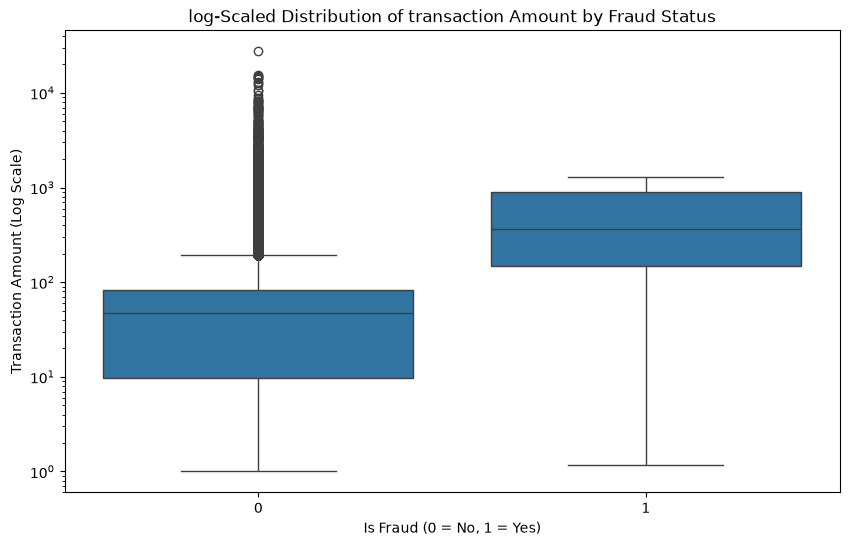

Observation: Fradulent transaction (1) typically have a significantly higher median transaction amount than legitimate ones.


In [15]:
plt.figure(figsize=(10,6))

sns.boxplot(x='is_fraud', y='amt', data=df)
plt.yscale('log')
plt.title('log-Scaled Distribution of transaction Amount by Fraud Status')
plt.xlabel('Is Fraud (0 = No, 1 = Yes)')
plt.ylabel('Transaction Amount (Log Scale)')
plt.show()

print("Observation: Fradulent transaction (1) typically have a significantly higher median transaction amount than legitimate ones.")

In [20]:
# Function to calculate outliers using IQR 
def detect_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = data[(data[column] < lower_bound) | (data[column] > upper_bound)]
    return len(outliers)

# Function calls (Indented fully to the left)
amt_outliers = detect_outliers_iqr(df, 'amt')
pop_outliers = detect_outliers_iqr(df, 'city_pop')

print(f"Total Outliers in 'amt': {amt_outliers}")
print(f"Total Outliers in 'city_pop': {pop_outliers}")

Total Outliers in 'amt': 20377
Total Outliers in 'city_pop': 72813


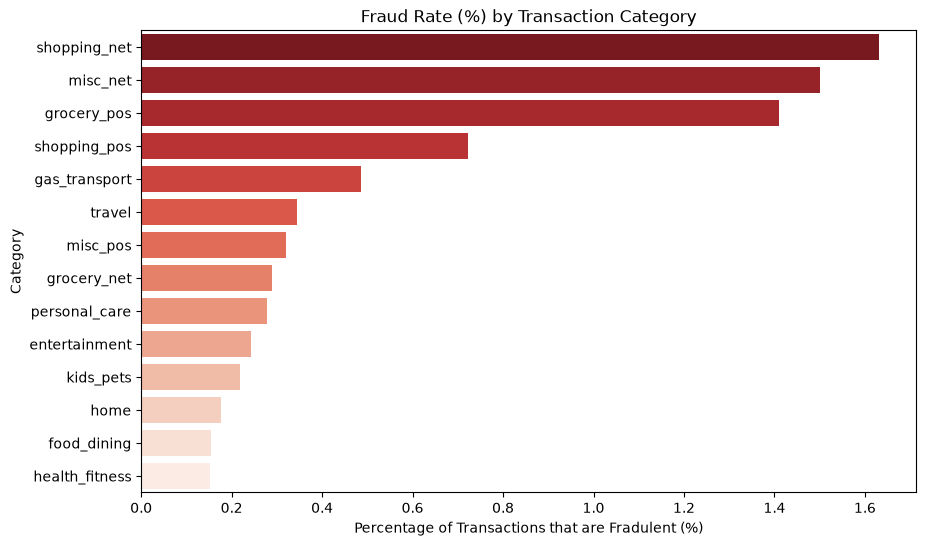

Observation: Grocery_pos and shopping_net typically show the highest normalised fraud rates, heavily influencing the target variable.


In [21]:
# Calcualting fraud rate per category to normaise for volume

fraud_by_category = df[df['is_fraud'] == 1]['category'].value_counts()
total_by_category = df['category'].value_counts()
fraud_rate = (fraud_by_category / total_by_category * 100).sort_values(ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x=fraud_rate.values, y=fraud_rate.index, palette='Reds_r')
plt.title('Fraud Rate (%) by Transaction Category')
plt.xlabel('Percentage of Transactions that are Fradulent (%)')
plt.ylabel('Category')
plt.show()

print("Observation: Grocery_pos and shopping_net typically show the highest normalised fraud rates, heavily influencing the target variable.")

Unparseable Dates: 0


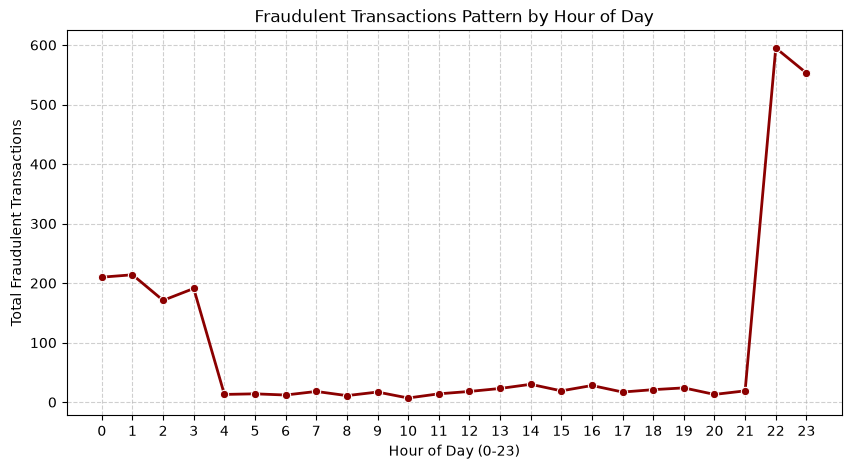

Observation: Fraud frequently spikes late at night (22:00 - 03:00) when legitimate transaction volume is lowest.


In [31]:
# 1. Reset the memory state by reloading the raw data
df = pd.read_csv('cc_data.csv')

# 2. Parse dates using dayfirst=True to handle Excel's DD-MM-YYYY formats robustly
df['trans_date_trans_time'] = pd.to_datetime(df['trans_date_trans_time'], dayfirst=True, errors='coerce')

# 3. Diagnostic check (This should print 0 if successful)
print(f"Unparseable Dates: {df['trans_date_trans_time'].isna().sum()}")

# 4. Extract hour and group
df['hour'] = df['trans_date_trans_time'].dt.hour
hourly_fraud = df[df['is_fraud'] == 1].groupby('hour').size()

# 5. Plot the visualization
plt.figure(figsize=(10, 5))
sns.lineplot(x=hourly_fraud.index, y=hourly_fraud.values, marker='o', color='darkred', linewidth=2)
plt.title('Fraudulent Transactions Pattern by Hour of Day')
plt.xlabel('Hour of Day (0-23)')
plt.ylabel('Total Fraudulent Transactions')
plt.xticks(range(0, 24))
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

print("Observation: Fraud frequently spikes late at night (22:00 - 03:00) when legitimate transaction volume is lowest.")

In [25]:
# Checking numerical correlation with the target variable 'is_fraud'
numeric_df = df.select_dtypes(include=[np.number])
target_corr = numeric_df.corr()['is_fraud'].sort_values(ascending=False)

print("--- Top Numerical Factors Influencing Fraud ---")
print(target_corr)
print("\nObservation: 'amt' (Transaction Amount) is the single highest numerical driver of fraud. Location coordinates and city population show near-zero direct correlation.")

--- Top Numerical Factors Influencing Fraud ---
is_fraud      1.000000
amt           0.210706
lat           0.002643
merch_lat     0.002406
long          0.001376
merch_long    0.001351
city_pop      0.001176
zip          -0.001220
cc_num       -0.001280
index        -0.006121
unix_time    -0.006562
hour               NaN
Name: is_fraud, dtype: float64

Observation: 'amt' (Transaction Amount) is the single highest numerical driver of fraud. Location coordinates and city population show near-zero direct correlation.


### SecureGuard Financial Solutions: Python EDA Report

**1. Data Structural Integrity & Inconsistencies:**
The dataset contains 389,002 transaction records. No missing values were detected, meaning no imputation was required. However, date string formats required parsing (`%d-%m-%Y %H:%M`) to extract time-series insights.

**2. Distribution & Outlier Anomalies:**
The transaction amount (`amt`) is heavily right-skewed. Using the IQR method, 20,377 transaction outliers were detected. In a fraud detection context, these outliers are critical signals rather than data entry errors, as fraudulent transactions possess a significantly higher median transaction amount than legitimate ones. City population (`city_pop`) showed 72,813 outliers but demonstrated near-zero correlation with fraud probability.

**3. Categorical & Time-Series Patterns:**
Fraud is not evenly distributed. Categorically, `grocery_pos` and `shopping_net` experience the highest proportional rates of fraud. Temporally, fraudulent activity spikes during late-night hours (22:00 to 03:00), indicating a clear behavioral pattern distinct from standard daytime commerce.

**4. Top Influencing Factors:**
Transaction amount is the primary numerical predictor of fraud. Geospatial features (latitude/longitude) and demographic size (`city_pop`) carry negligible direct linear correlation. Future predictive modeling should rely heavily on transaction amount, merchant category, and hour-of-day feature engineering.